<a href="https://colab.research.google.com/github/anamika29lj/-ai-notes-generating-system/blob/main/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Anamika Jagram Lodhi

Batch : CE02

Roll Number : CE22



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset from sklearn
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the diagnosis target column and 'id' / 'Unnamed: 32' to match subsequent task structures
df["diagnosis"] = data.target
df["diagnosis"] = df["diagnosis"].map({1: "M", 0: "B"})  # M for malignant, B for benign
df["id"] = np.arange(len(df))
df["Unnamed: 32"] = np.nan

# Display first 5 rows
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst area  worst smoothness  \
0                 0.07871  .

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape:
(569, 33)

Column Names:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis', 'id', 'Unnamed: 32'],
      dtype='object')

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64


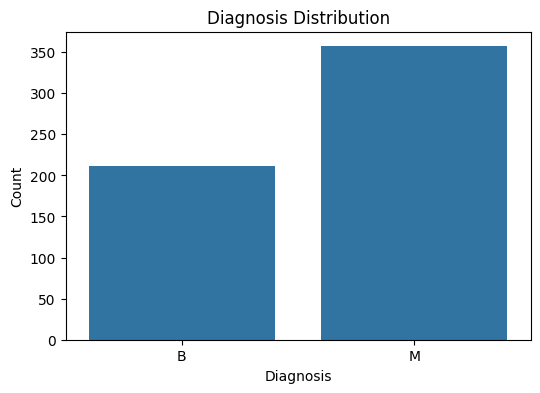

In [ ]:
# Task 2: Explore the Dataset

# Display shape of dataset
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Display diagnosis distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# Plot diagnosis distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Task 3: Data Cleaning and Feature/Target Selection

# Drop unnecessary columns
df = df.drop(["id", "Unnamed: 32"], axis=1)

# Convert diagnosis:
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Feature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nFirst 5 Feature Rows:")
print(X.head())

print("\nFirst 5 Target Values:")
print(y.head())

Feature Shape:
(569, 30)

Target Shape:
(569,)

First 5 Feature Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimens

# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Task 4: Standardize Features

# Create StandardScaler object
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

# Display first 5 rows
print("First 5 rows of standardized data:")
print(X_scaled[:5])

# Check mean
print("\nMean of standardized features:")
print(X_scaled.mean(axis=0))

# Check standard deviation
print("\nStandard deviation of standardized features:")
print(X_scaled.std(axis=0))

First 5 rows of standardized data:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.4

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Task 5: Implement PCA (30D to 2D)

# Create PCA object with 2 components
pca = PCA(n_components=2)

# Transform standardized data
X_pca = pca.fit_transform(X_scaled)

# Display shapes
print("Original Data Shape:")
print(X_scaled.shape)

print("\nPCA Data Shape:")
print(X_pca.shape)

# Display first 5 PCA values
print("\nFirst 5 PCA transformed values:")
print(X_pca[:5])

Original Data Shape:
(569, 30)

PCA Data Shape:
(569, 2)

First 5 PCA transformed values:
[[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


Variance explained by PC1:
0.44272025607526366

Variance explained by PC2:
0.1897118204403308

Cumulative variance:
[0.44272026 0.63243208]

Total variance retained:
0.6324320765155944

Total variance retained (%):
63.243207651559445


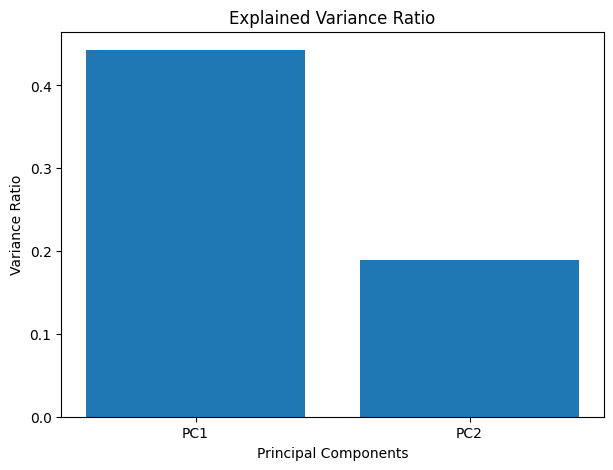

In [ ]:
# Task 6: Analyze Explained Variance Ratio

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Print variance explained by PC1
print("Variance explained by PC1:")
print(explained_variance[0])

# Print variance explained by PC2
print("\nVariance explained by PC2:")
print(explained_variance[1])

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative variance:")
print(cumulative_variance)

# Print total variance retained
print("\nTotal variance retained:")
print(cumulative_variance[-1])

print("\nTotal variance retained (%):")
print(cumulative_variance[-1] * 100)

# Plot explained variance
plt.figure(figsize=(7, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance
)

plt.title("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")

plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

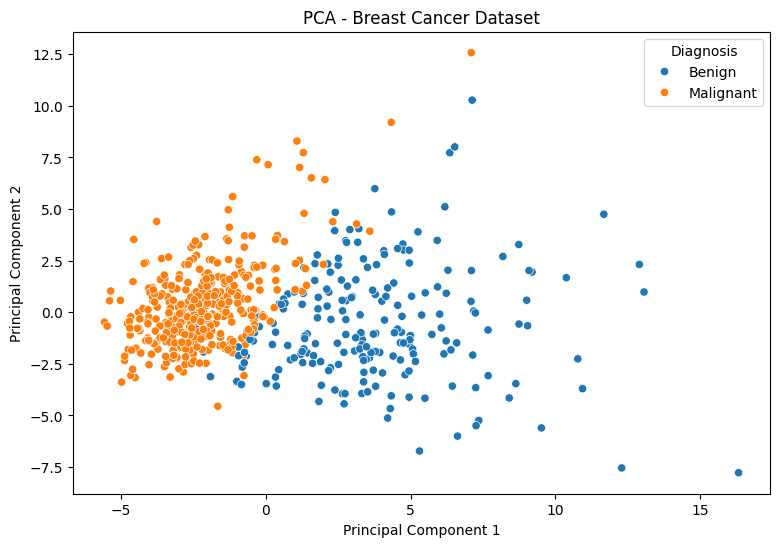

In [ ]:

# Task 7: Visualize PCA Transformed Data

# Create DataFrame for PCA data
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add diagnosis column
pca_df["Diagnosis"] = y.values

# Convert diagnosis numbers to labels
pca_df["Diagnosis"] = pca_df["Diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})

# Create scatter plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis"
)

plt.title("PCA - Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Diagnosis")

plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Task 8: Train Classifier on Raw High-Dimensional Data

# Split the original scaled dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
model_raw = LogisticRegression(max_iter=1000)

# Train the model
model_raw.fit(X_train, y_train)

# Make predictions
y_pred_raw = model_raw.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression using 30 Features")
print("--------------------------------------")
print("Accuracy:", accuracy_raw)

# Confusion Matrix
cm_raw = confusion_matrix(y_test, y_pred_raw)

print("\nConfusion Matrix:")
print(cm_raw)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_raw,
        target_names=["Benign", "Malignant"]
    )
)

Logistic Regression using 30 Features
--------------------------------------
Accuracy: 0.9824561403508771

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        42
   Malignant       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Task 9: Train Classifier on PCA Transformed Data

# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
model_pca = LogisticRegression(max_iter=1000)

# Train the model
model_pca.fit(X_train_pca, y_train_pca)

# Make predictions
y_pred_pca = model_pca.predict(X_test_pca)

# Calculate accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("Logistic Regression using 2 PCA Components")
print("------------------------------------------")
print("Accuracy:", accuracy_pca)

# Confusion Matrix
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

print("\nConfusion Matrix:")
print(cm_pca)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"]
    )
)

Logistic Regression using 2 PCA Components
------------------------------------------
Accuracy: 0.9473684210526315

Confusion Matrix:
[[40  2]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.95      0.93        42
   Malignant       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
# Task 10: Compare Classifier Performance

print("==============================================")
print("       CLASSIFICATION PERFORMANCE")
print("==============================================")

# Accuracy comparison
print("\nAccuracy using 30 Original Features:")
print(accuracy_raw)

print("\nAccuracy using 2 PCA Components:")
print(accuracy_pca)


# ==============================================
# Confusion Matrix - Original 30 Features
# ==============================================

print("\n==============================================")
print("Confusion Matrix - 30 Original Features")
print("==============================================")

print(cm_raw)


# ==============================================
# Confusion Matrix - PCA
# ==============================================

print("\n==============================================")
print("Confusion Matrix - 2 PCA Components")
print("==============================================")

print(cm_pca)


# ==============================================
# Classification Report - Original
# ==============================================

print("\n==============================================")
print("Classification Report - 30 Features")
print("==============================================")

print(
    classification_report(
        y_test,
        y_pred_raw,
        target_names=["Benign", "Malignant"]
    )
)


# ==============================================
# Classification Report - PCA
# ==============================================

print("\n==============================================")
print("Classification Report - PCA")
print("==============================================")

print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"]
    )
)

       CLASSIFICATION PERFORMANCE

Accuracy using 30 Original Features:
0.9824561403508771

Accuracy using 2 PCA Components:
0.9473684210526315

Confusion Matrix - 30 Original Features
[[41  1]
 [ 1 71]]

Confusion Matrix - 2 PCA Components
[[40  2]
 [ 4 68]]

Classification Report - 30 Features
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        42
   Malignant       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Classification Report - PCA
              precision    recall  f1-score   support

      Benign       0.91      0.95      0.93        42
   Malignant       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.